In [2]:
%load_ext autoreload
%autoreload 2

# general
from pathlib import Path
import re
import numpy as np
import datetime
import matplotlib.pyplot as plt
import itertools
from tqdm.auto import tqdm
import yaml
import subprocess

# spatial
import xarray as xa
import xarray as xa

# custom
from cmipper import utils, config, file_ops, processing

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Integrating `esgpull`

`esgpull` provides streamlined, maintained functionality to search and download files from the `esgf-node` servers. The job of this notebook is to substitute my own downloading schema (developed as `cmipper`) for `esgpull` while retaining the additional functionality I require. This is:
- ~~Consistent, human-readable file labelling~~ -> Happy with what's given, keeping for simplicity
- Regridding from variable grid to fixed grid
- POTENTIALLY – concatenating and cropping variables

This should enable faster, more reliable, and better-logged downloading of all necessary GCM variables in a 'one file' approach. The user should be able to specify which variables (at what resolution, over a specified time period), which model ensembles, and how many model runs they want for each. The program should then attempt to download these N times.

### Variables
| variable_long_name                                           | variable_id | variable_units | frequency                       | levels         | spatial resolution(s)         |
|--------------------------------------------------------------|-------------|----------------|---------------------------------|----------------|-------------|
|                                                              |             |                |                                 |                |              |
| Sea Surface Temperature                                      | tos         | [degC]         | 3hr, Amon, Oday, Odec, **Omon** | surface only   | 
| Sea Water Potential Temperature                              | thetao      | [degC]         | Omon                            | multiple       |
| Surface Downwelling Shortwave Radiation                      | rsds        | [W m-2]        | 3hr, Amon, CFsubhr, ImonAnt, ImonGre, day | surface only   |
| ~~Downwelling Shortwave Radiation in Sea Water~~                 | rsdo        | [W m-2]        | Omon                            | surface only   |
| Sea Water Salinity                                           | so          | [0.001]        | Omon                            | multiple       |
| Sea Water X Velocity                                         | uo          | [m s-1]        | Odec, **Omon**                  | multiple       |
| Sea Water Y Velocity                                         | vo          | [m s-1]        | Odec, **Omon**                  | multiple       |
| Aragonite Concentration                                      | arag        | [mol m-3]      | Oyr                             | ? |   100km, 1x1º, 250km  |
| Dissolved Nitrate Concentration                              | no3         | [mol m-3]      | **Omon**, Oyr                   | ? |
| Total Dissolved Inorganic Phosphorus Concentration           | po4         | [mol m-3]      | **Omon**, Oyr                   | ? |


N.B. `arag`, `po4`, `no3` – no `hist-1950`, only `historical`. For these edge-case variables also necessary to have different models in past and forecast, since they only have one or the other. Only way around this is ensembling. N.B. this may be mostly due to the high-res restriction (50km I had on): need to check this. 

Currently downloading 6 model runs.

Working list:
1. ~~For an example ensemble (`HadGEM3-GC31-MM`) and variable (`tos`), search and download via command-line~~
2. ~~Automate this with a bash script~~ Done to some extent by generating query from yaml file
3. Pipe downloads into regridder

Example query:
`$ esgpull search project:CMIP6 experiment_id:historical institution_id:HadGEM3-GC31-MM variable_id:tos table_id:Omon member_id:r1i1p1f1 --distrib true --show`

In [6]:
# creating searchs from yaml

with open('/maps/rt582/cmipper/tmp/data_to_download.yaml', 'r') as file:
    data_config = yaml.safe_load(file)

# Start the command as a list
query = ["esgpull", "search"]

# Add parameters, handling spaces by keeping each argument separate
for param, value in data_config.items():
    if not isinstance(value, list):
        # If there's a space, wrap value in quotes
        query.append(f"{param}:{value}" if ' ' not in str(value) else f"{param}:'{value}'")
    else:
        # Join list values with commas and wrap if they have spaces
        joined_values = ','.join([f"'{v}'" if ' ' in str(v) else v for v in value])
        query.append(f"{param}:{joined_values}")

# Add the distribution flag
query.append("--distrib")
query.append("true")

# Display the final command
print("Running:\n", ' '.join(query))

# Uncomment to execute the command
# subprocess.run(query)

Running:
 esgpull search project:CMIP6 institution_id:CSIRO,NOAA-GFDL experiment_id:hist-1950,historical,ssp126,ssp245,ssp370,ssp585 table_id:Omon,Amon variant_label:r1i1p1f1,r2i1p1f1,r3i1p1f1,r4i1p1f1,r5i1p1f1,r6i1p1f1 variable_id:arag,no3,po4 --distrib true


# Testing processing functions

In [ ]:
# open test file
test_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/vo/gn/v20170915/vo_Omon_ECMWF-IFS-HR_hist-1950_r1i1p1f1_gn_195001-195012.nc"
# select level
out = processing.extract_dataset_level(test_fp, 0)

<xarray.Dataset> Size: 82MB
Dimensions:    (time: 12, i: 1021, j: 1442)
Coordinates:
  * time       (time) datetime64[ns] 96B 1973-01-16T12:00:00 ... 1973-12-16T1...
  * i          (i) int32 4kB 1 2 3 4 5 6 7 ... 1016 1017 1018 1019 1020 1021
  * j          (j) int32 6kB 1 2 3 4 5 6 7 ... 1437 1438 1439 1440 1441 1442
    latitude   (i, j) float32 6MB -77.01 -77.01 -77.01 ... 50.0 49.99 49.99
    longitude  (i, j) float32 6MB 72.88 73.12 73.38 73.62 ... 73.0 73.0 73.0
Data variables:
    uo         (time, i, j) float32 71MB ...

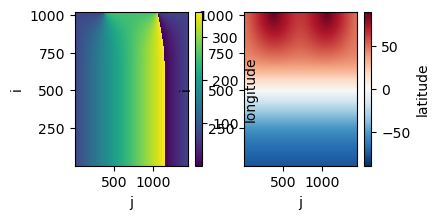

In [103]:
# processing error
test_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/uo/gn/v20170915/uo_Omon_ECMWF-IFS-HR_hist-1950_r1i1p1f1_gn_197301-197312.nc"
check = processing.extract_dataset_level(test_fp, 0)
check = check.drop_vars(['vertices_latitude', 'vertices_longitude', 'time_bnds'])

fig, ax = plt.subplots(1,2, figsize=(4,2))
check.longitude.plot(ax=ax[0])
check.latitude.plot(ax=ax[1])
check

In [97]:
# sort remapping template
OUTPUT_GRID = "latlon"
REMAP_METHOD = "bilinear"
remap_template_fp = processing.handle_cdo_template(
                    check,
                    config.TMP_DIR,
                    OUTPUT_GRID,
                )

# remove vertices_latitude, vertices_longitude
# remap_template_fp  = "/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/EC-Earth3P-HR_remap_template.txt"
utils.cdo_remap(
                    check,
                    remap_template_fp=remap_template_fp,
                    remap_method=REMAP_METHOD,
                )



Using existing remapping template at  /maps-priv/maps/rt582/cmipper/tmp/latlon_remap_template.txt
Error in calling operator remapbil with:
>>> cdo -O -s -f nc -remapbil,/maps-priv/maps/rt582/cmipper/tmp/latlon_remap_template.txt /tmp/cdoPywaidb9qo /tmp/cdoPy2_jtqyt0<<<
STDOUT:
STDERR:cdi  warning (cdfInqContents): Coordinates variable latitude can't be assigned!
cdi  warning (cdfInqContents): Coordinates variable longitude can't be assigned!

cdo    remapbil (Abort): Unsupported generic coordinates (Variable: uo)!



CDOException: (returncode:1) cdi  warning (cdfInqContents): Coordinates variable latitude can't be assigned!
cdi  warning (cdfInqContents): Coordinates variable longitude can't be assigned!

cdo    remapbil (Abort): Unsupported generic coordinates (Variable: uo)!


In [107]:
from cdo import Cdo
cdo = Cdo()
utils.cdo_remap(check, remap_template_fp=remap_template_fp, remap_method=REMAP_METHOD)

<xarray.Dataset> Size: 71MB
Dimensions:  (time: 12, lon: 1442, lat: 1021)
Coordinates:
  * time     (time) datetime64[ns] 96B 1973-01-16T12:00:00 ... 1973-12-16T12:...
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.3 179.5 179.7
  * lat      (lat) float64 8kB -77.01 -76.85 -76.68 -76.52 ... 89.47 89.63 89.8
Data variables:
    uo       (time, lat, lon) float32 71MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Nov 06 11:36:41 2024: cdo -O -s -f nc -remapbil,/maps-p...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [86]:
fp = "/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/r1i1p2f1/og_grid/hfds/hfds_uncropped_sfc_tp_195001-195012.nc"
check_works = xa.open_dataset(fp)
check_works
# remap_template_fp = "/maps/rt582/cmipper/data/env_vars/cmip6/EC-Earth3P-HR/EC-Earth3P-HR_remap_template.txt"

<xarray.Dataset> Size: 85MB
Dimensions:    (time: 12, j: 1050, i: 1442)
Coordinates:
  * time       (time) datetime64[ns] 96B 1950-01-16T12:00:00 ... 1950-12-16T1...
  * j          (j) int32 4kB 1 2 3 4 5 6 7 ... 1045 1046 1047 1048 1049 1050
  * i          (i) int32 6kB 1 2 3 4 5 6 7 ... 1437 1438 1439 1440 1441 1442
    latitude   (j, i) float32 6MB ...
    longitude  (j, i) float32 6MB ...
Data variables:
    hfds       (time, j, i) float32 73MB ...

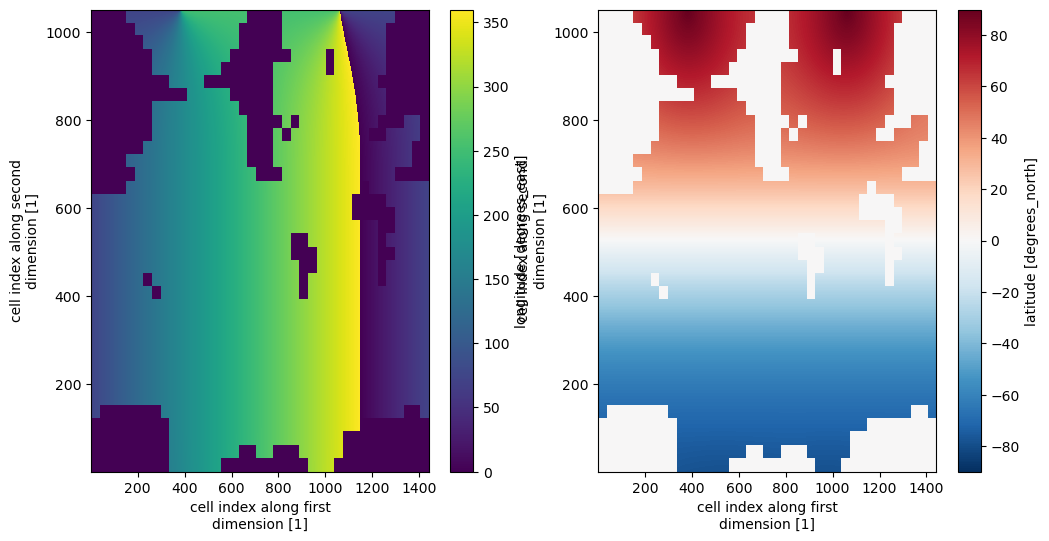

In [93]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
check_works.longitude.plot(ax=ax[0])
check_works.latitude.plot(ax=ax[1])

## Stepping into py

In [1]:
%load_ext autoreload
%autoreload 2

from cmipper import extract_levels
from pathlib import Path
dir_fp = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev")
extract_levels.process_raw_data_directory(dir_fp, None)

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using existing remapping template at  /maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/latlon_remap_template.txt


Regridding /maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev...: 100%|██████████| 55/55 [00:00<00:00, 4496.20it/s]

/maps-priv/maps/rt582/cmipper/data/test/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_197601-197612.nc already exists.
/maps-priv/maps/rt582/cmipper/data/test/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_201101-201112.nc already exists.
/maps-priv/maps/rt582/cmipper/data/test/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_195501-195512.nc already exists.
/maps-priv/maps/rt582/cmipper/data/test/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_199601-199612.nc already exists.
/maps-priv/maps/rt582/cmipper/data/test/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev/so_Omon_ECMWF-IFS-HR_hist-1950_r3i1p1f1_gn_196

# Processing resulting files

In [7]:
raw_data_dir = Path('/maps/rt582/cmipper/.esgpull/data/')
processed_data_dir = Path('/maps/rt582/cmipper/data/test/')

file_path = Path(test_fp)
rel_path = file_path.relative_to(raw_data_dir)

output_path = processed_data_dir / rel_path
output_path.parent.mkdir(parents=True, exist_ok=True)

# processing metadata
with open('/maps/rt582/cmipper/tmp/data_processing.yaml', 'r') as file:
    data_processing_config = yaml.safe_load(file)

select_level = data_processing_config["select_level"]
do_regrid = data_processing_config["do_regrid"]
output_grid = data_processing_config["output_grid"]
remap_method = data_processing_config["remap_method"]
do_delete_original = data_processing_config["do_delete_original"]

NameError: name 'test_fp' is not defined

In [ ]:
remap_template_fp = output_path.parent / "remap_template.txt"
# generate remap file if necessary
remap_template_fp = utils.return_remap_template(input_file=out, remap_template_fp=remap_template_fp, out_grid=output_grid)

In [137]:
test = processing.reproject_xa_d(xa_d=out, ds_fp=test_fp, output_grid=output_grid, remap_method=remap_method)

Using existing remapping template at  /maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/vo/gn/v20170915/latlon_remap_template.txt


## Processing files once they've been downloaded
(Rather than on the fly)



In [111]:
# for nc files in the lowest directories

# fetch all subdirectories
subdirs = [subdir for subdir in Path(raw_data_dir).glob("**/") 
                  if "deprecated" not in str(subdir) and subdir.is_dir()]

# select correct level(s)
for subdir in tqdm(subdirs, desc="Processing raw data to extract levels...", total = len(subdirs)):
    print(subdir)
    processing.process_raw_data_directory(subdir, chunk_schema=None, delete_og=do_delete_original)
# resave to same fp
# regrid to new location

Processing raw data to extract levels...:   0%|          | 0/113 [00:00<?, ?it/s]

/maps/rt582/cmipper/.esgpull/data
/maps/rt582/cmipper/.esgpull/data/CMIP6
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP
/maps/rt582/cmipper/.esgpull/data/CMIP6/ScenarioMIP
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r2i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r6i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r5i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r4i1p1f1
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3

Processing raw data to extract levels...:  19%|█▊        | 21/113 [00:00<00:02, 35.05it/s]

/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/tmp_test
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/uo/gn
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/uo/gn/v20181119
/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/uo/gn/v20181119/extracted_lev


Processing raw data to extract levels...:  22%|██▏       | 25/113 [00:00<00:03, 26.03it/s]

...

	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r2i1p1f1_gn_199701-199712...


	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r2i1p1f1_gn_195401-195412...


	Processing so_Omon_ECMWF-IFS-HR_hist-1950_r2i1p1f1_gn_197001-197012...


Processing raw data to extract levels...:  39%|███▉      | 44/113 [13:14<20:46, 18.06s/it]


KeyboardInterrupt: 

In [107]:
fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r2i1p1f1/Omon/uo/gn/v20181119/uo_Omon_ECMWF-IFS-HR_hist-1950_r2i1p1f1_gn_201401-201412.nc"
check = xa.open_dataset(fp)
check

<xarray.Dataset> Size: 130MB
Dimensions:             (time: 12, bnds: 2, i: 1021, j: 1442, vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 96B 2014-01-16T12:00:00 ... 201...
  * i                   (i) int32 4kB 1 2 3 4 5 6 ... 1017 1018 1019 1020 1021
  * j                   (j) int32 6kB 1 2 3 4 5 6 ... 1438 1439 1440 1441 1442
    latitude            (i, j) float32 6MB ...
    longitude           (i, j) float32 6MB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 192B ...
    vertices_latitude   (i, j, vertices) float32 24MB ...
    vertices_longitude  (i, j, vertices) float32 24MB ...
    uo                  (time, i, j) float32 71MB ...

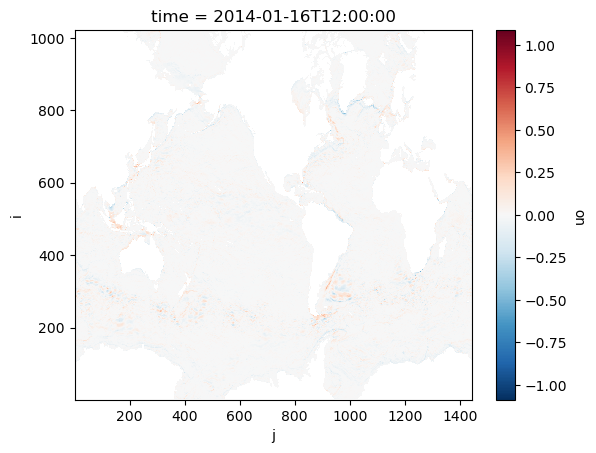

In [108]:
check.isel(time=0).uo.plot()

## Finding most efficient chunking for processing functions

### Reprojection

In [53]:
test_fp = "/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r1i1p1f1/Omon/tos/gn/v20170915/tos_Omon_ECMWF-IFS-HR_hist-1950_r1i1p1f1_gn_195001-195012.nc"
ds_eg = processing.load_dataset_with_dask(test_fp)

# sort remapping template
OUTPUT_GRID = "latlon"
REMAP_METHOD = "bilinear"
remap_template_fp = processing.handle_cdo_template(
                    ds_eg,
                    config.TMP_DIR,
                    OUTPUT_GRID,
                )

Using existing remapping template at  /maps-priv/maps/rt582/cmipper/tmp/latlon_remap_template.txt


In [55]:
import time

def benchmark_chunking_schemas(ds, remap_template_fp, remap_method, schemas):
    times = {}
    
    for name, chunks in schemas.items():
        print(f"Testing chunking schema: {name}")
        
        # Re-chunk the dataset based on the current schema
        ds_chunked = ds.chunk(chunks)
        
        # Start the timer and apply extraction function
        start_time = time.time()
        
        utils.cdo_remap(
                            ds,
                            remap_template_fp=remap_template_fp,
                            remap_method=remap_method,
                        )
        
        # Record the time taken
        times[name] = time.time() - start_time
        print(f"\tTime for {name}: {times[name]:.2f} seconds")
        
    return times

# Define your chunking schemas
chunk_schema = {
    "auto": "auto",
    "all_time": {"time": -1},
    "all_space": {"i": -1, "j": -1},
    "None": None,
}

# Run the benchmark
times = benchmark_chunking_schemas(ds_eg, remap_template_fp, REMAP_METHOD, chunk_schema)
print("Chunking times:", times)


Testing chunking schema: auto
Time for auto: 8.23 seconds
Testing chunking schema: all_levs
Time for all_levs: 8.25 seconds
Testing chunking schema: all_time
Time for all_time: 7.79 seconds
Testing chunking schema: all_space
Time for all_space: 8.12 seconds
Testing chunking schema: None
Time for None: 7.75 seconds
Chunking times: {'auto': 8.226726770401001, 'all_levs': 8.24630856513977, 'all_time': 7.792144775390625, 'all_space': 8.11618971824646, 'None': 7.746342658996582}


/tmp/ipykernel_3887652/4055431895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Key', y='Value', palette="viridis")


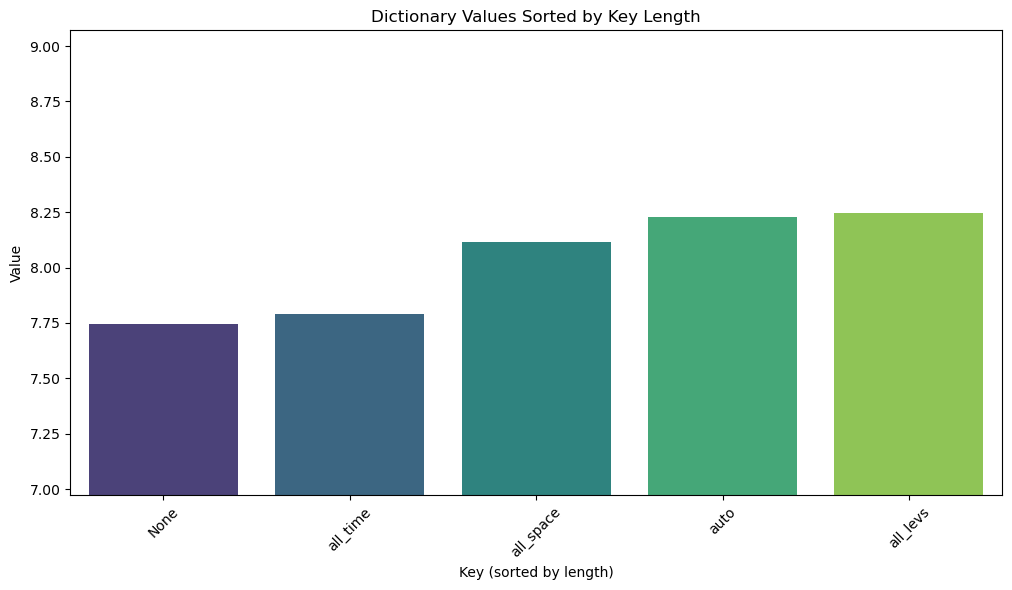

In [56]:
import pandas as pd
import seaborn as sns
sorted_times = dict(sorted(times.items(), key=lambda item: item[1]))
# Convert to DataFrame for easier plotting
df = pd.DataFrame(list(sorted_times.items()), columns=['Key', 'Value'])
df['Key_Length'] = df['Key'].apply(len)  # Add a column for key length if you want to color by this

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Key', y='Value', palette="viridis")

# Customize plot
plt.xlabel("Key (sorted by length)")
plt.ylabel("Value")
plt.title("Dictionary Values Sorted by Key Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(min(times.values()) * 0.9, max(times.values()) * 1.1)
plt.show()


### Level extraction

In [43]:
ds_eg = processing.load_dataset_with_dask(test_fp, chunk_schema={"time": 1, "lev": -1})
# extract seafloor indices 
seafloor_inds = processing.gen_seafloor_indices(ds_eg, "vo")


determining seafloor indices... 


In [ ]:
import time

def benchmark_chunking_schemas(ds, variable_id, seafloor_indices, schemas):
    times = {}
    
    for name, chunks in schemas.items():
        print(f"Testing chunking schema: {name}")
        
        # Re-chunk the dataset based on the current schema
        ds_chunked = ds.chunk(chunks)
        
        # Start the timer and apply extraction function
        start_time = time.time()
        
        # Extract seafloor values with the current chunking schema
        processing.extract_seafloor_vals_from_ds(ds_chunked, variable_id, seafloor_indices)
        
        # Record the time taken
        times[name] = time.time() - start_time
        print(f"Time for {name}: {times[name]:.2f} seconds")
        
    return times

# Define your chunking schemas
chunk_schema = {
    "auto": "auto",
    "all_levs": {"time": 1, "lev": -1},
    "all_time": {"time": -1, "lev": 1},
    "all_time_all_levs": {"time": -1, "lev": -1},
    "None": None,
    "balanced": {"time": 5, "lev": 10},
    "lev_10": {"time": 1, "lev": 10},
    "lev_20": {"time": 1, "lev": 20},
    "lev_30": {"time": 1, "lev": 30},
    "lev_40": {"time": 1, "lev": 40},
    "lev_50": {"time": 1, "lev": 50},
    "lev_60": {"time": 1, "lev": 60},
    "lev_70": {"time": 1, "lev": 70},
}

# Run the benchmark
times = benchmark_chunking_schemas(ds_eg, "vo", seafloor_inds, chunk_schema)
print("Chunking times:", times)

Testing chunking schema: None
Time for None: 26.96 seconds
Chunking times: {'None': 26.95549964904785}


/tmp/ipykernel_3726440/4055431895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Key', y='Value', palette="viridis")


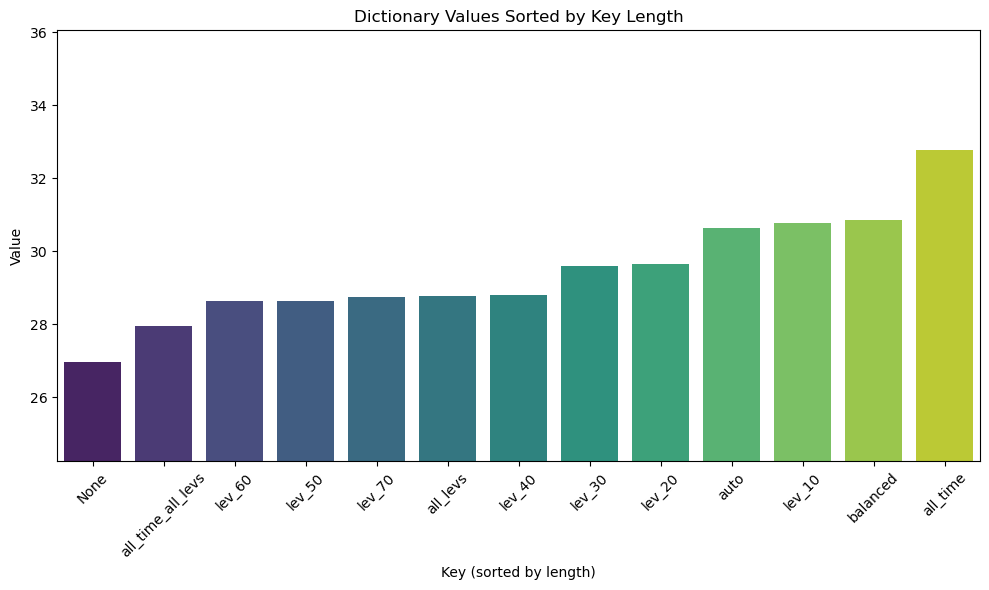

In [82]:
import pandas as pd
import seaborn as sns
sorted_times = dict(sorted(times.items(), key=lambda item: item[1]))
# Convert to DataFrame for easier plotting
df = pd.DataFrame(list(sorted_times.items()), columns=['Key', 'Value'])
df['Key_Length'] = df['Key'].apply(len)  # Add a column for key length if you want to color by this

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Key', y='Value', palette="viridis")

# Customize plot
plt.xlabel("Key (sorted by length)")
plt.ylabel("Value")
plt.title("Dictionary Values Sorted by Key Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(min(times.values()) * 0.9, max(times.values()) * 1.1)
plt.show()


# Checking that all files have been downloaded/processed

In [48]:
from pathlib import Path

def check_file_counts(main_dir: Path, expected_count: int = 65):
    """Check that each lowest-level subdirectory contains the expected number of .nc files.

    Args:
        main_dir (Path): The main directory containing the subdirectories.
        expected_count (int): The expected number of .nc files in each lowest-level subdirectory.

    Returns:
        dict: A dictionary with subdirectory paths as keys and actual file counts as values for those not matching expected count.
    """
    mismatch_counts = {}

    num_counts = 0
    # Loop through each subdirectory in main directory
    for subdir in main_dir.glob("**/"):
        # Only check if it is a lowest-level directory with .nc files
        if any(subdir.glob("*.nc")):
            nc_files = list(subdir.glob("*.nc"))
            file_count = len(nc_files)
            if file_count != expected_count:
                mismatch_counts[subdir] = file_count
                num_counts += 1

    if mismatch_counts:
        print(f"Mismatched file counts found in {num_counts} directories:")
        for subdir, count in mismatch_counts.items():
            print(f"{subdir}: {count} files (expected {expected_count})")
    else:
        print("All subdirectories contain the expected number of files.")

    return mismatch_counts


mismatches = check_file_counts(config.ESGPULL_DATA_DIR / "CMIP6", expected_count=65)

Mismatched file counts found in 35 directories:
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119: 20 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/so/gn/v20181119/extracted_lev: 55 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/uo/gn/v20181119: 37 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/uo/gn/v20181119/extracted_lev: 33 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/thetao/gn/v20181119: 1 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/data/CMIP6/HighResMIP/ECMWF/ECMWF-IFS-HR/hist-1950/r3i1p1f1/Omon/thetao/gn/v20181119/extracted_lev: 21 files (expected 65)
/maps-priv/maps/rt582/cmipper/.esgpull/

# Some homework from `coralshift`

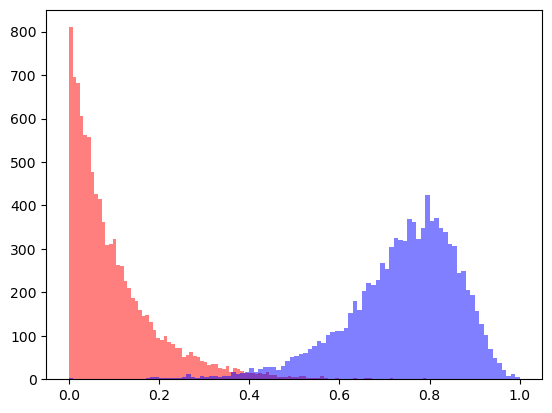

In [45]:
def log_transform_y(y, epsilon=1e-5):
    """
    Applies a log transformation to the target variable y, while ensuring the output remains between 0 and 1.
    
    Parameters:
        y (array-like): The target data array with values between 0 and 1.
        epsilon (float): Small constant to prevent taking log of zero, default is 1e-5.
        
    Returns:
        transformed_y (array-like): Log-transformed target data scaled to the range [0, 1].
    """
    # Scale y to a range that avoids exact zero (e.g., [epsilon, 1]) to prevent log(0)
    y_scaled = (y * (1 - epsilon)) + epsilon
    
    # Apply log transformation
    y_log = np.log(y_scaled)
    
    # Rescale to [0, 1] after log transformation
    y_min, y_max = y_log.min(), y_log.max()
    transformed_y = (y_log - y_min) / (y_max - y_min)
    
    return transformed_y



# generate me a dataset between 0 and 1 highly skewed towards low values
plt.hist(y, alpha=0.5, bins=100, color="r");
plt.hist(log_transform_y(y), alpha=0.5, bins=100, color="b");

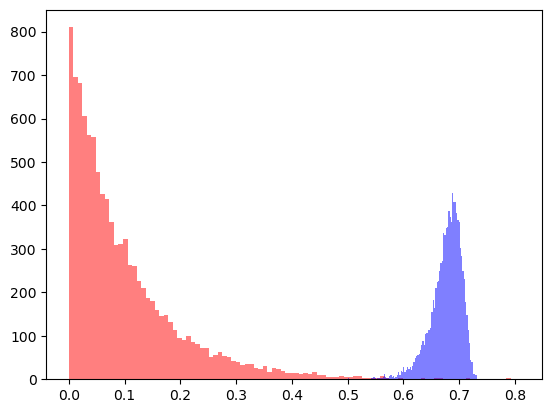

In [47]:
import numpy as np

def inverse_log_transform_y(transformed_y):
    """
    Reverses the log transformation applied to the target data.
    
    Parameters:
        transformed_y (array-like): The log-transformed target data, assumed to be the result of log(y / (1 - y)).
        
    Returns:
        original_y (array-like): The original target data, scaled between 0 and 1.
    """
    # Apply the inverse of the log transformation (logistic function)
    original_y = 1 / (1 + np.exp(-transformed_y))
    
    return original_y

plt.hist(y, alpha=0.5, bins=100, color="r");
plt.hist(inverse_log_transform_y(log_transform_y(y)), alpha=0.5, bins=100, color="b");